<b> After filling the null values with mean values, which results 0 for values of some column. 
    In this, those values are not removed 

In [59]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
from scipy import stats
import seaborn as sns 
import pickle
import joblib
import streamlit as st
sns.set()

In [60]:
# reading the dataset
data = pd.read_excel('Specific_purpose_of_kidnapping_and_abduction.xlsx', sheet_name='Sheet2')
data.head()

,Area_Name,Year,Group_Name,Sub_Group_Name,K_A_Cases_Reported,K_A_Female_10_15_Years,K_A_Female_15_18_Years,K_A_Female_18_30_Years,K_A_Female_30_50_Years,K_A_Female_Above_50_Years,K_A_Female_Total,K_A_Female_Upto_10_Years,K_A_Grand_Total,K_A_Male_10_15_Years,K_A_Male_15_18_Years,K_A_Male_18_30_Years,K_A_Male_30_50_Years,K_A_Male_Above_50_Years,K_A_Male_Total,K_A_Male_Upto_10_Years
0,Andhra Pradesh,2010,Kidnap - For Adoption,01. For Adoption,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,0.0,0.0,0.0,2.0,0.0,3.0,1.0
1,Arunachal Pradesh,2010,Kidnap - For Adoption,01. For Adoption,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Bihar,2010,Kidnap - For Adoption,01. For Adoption,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,2.0,NaN,1.0,2.0,NaN,6.0,1.0
3,Chhattisgarh,2010,Kidnap - For Adoption,01. For Adoption,3,0.0,3.0,0.0,0.0,0.0,3.0,0.0,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Delhi,2010,Kidnap - For Adoption,01. For Adoption,1,NaN,NaN,NaN,NaN,NaN,0.0,NaN,1,NaN,NaN,NaN,NaN,NaN,1.0,1.0


In [61]:
# making a copy of the dataset
data1 = data
data1

,Area_Name,Year,Group_Name,Sub_Group_Name,K_A_Cases_Reported,K_A_Female_10_15_Years,K_A_Female_15_18_Years,K_A_Female_18_30_Years,K_A_Female_30_50_Years,K_A_Female_Above_50_Years,K_A_Female_Total,K_A_Female_Upto_10_Years,K_A_Grand_Total,K_A_Male_10_15_Years,K_A_Male_15_18_Years,K_A_Male_18_30_Years,K_A_Male_30_50_Years,K_A_Male_Above_50_Years,K_A_Male_Total,K_A_Male_Upto_10_Years
0,Andhra Pradesh,2010,Kidnap - For Adoption,01. For Adoption,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,0.0,0.0,0.0,2.0,0.0,3.0,1.0
1,Arunachal Pradesh,2010,Kidnap - For Adoption,01. For Adoption,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Bihar,2010,Kidnap - For Adoption,01. For Adoption,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,2.0,NaN,1.0,2.0,NaN,6.0,1.0
3,Chhattisgarh,2010,Kidnap - For Adoption,01. For Adoption,3,0.0,3.0,0.0,0.0,0.0,3.0,0.0,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Delhi,2010,Kidnap - For Adoption,01. For Adoption,1,NaN,NaN,NaN,NaN,NaN,0.0,NaN,1,NaN,NaN,NaN,NaN,NaN,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,Tamil Nadu,2010,Kidnap - For Other Purposes,13. Other Purposes,483,15.0,62.0,118.0,31.0,3.0,241.0,12.0,488,4.0,2.0,87.0,136.0,11.0,247.0,7.0
315,Tripura,2010,Kidnap - For Other Purposes,13. Other Purposes,33,3.0,3.0,9.0,5.0,0.0,20.0,0.0,34,1.0,NaN,6.0,6.0,0.0,14.0,1.0
316,Uttar Pradesh,2010,Kidnap - For Other Purposes,13. Other Purposes,792,18.0,13.0,39.0,12.0,0.0,85.0,3.0,792,29.0,38.0,390.0,221.0,8.0,707.0,21.0
317,Uttarakhand,2010,Kidnap - For Other Purposes,13. Other Purposes,123,NaN,NaN,59.0,29.0,NaN,88.0,NaN,123,3.0,5.0,23.0,4.0,NaN,35.0,NaN


In [62]:
data1.shape

(319, 20)

In [63]:
data1.describe()

,Year,K_A_Cases_Reported,K_A_Female_10_15_Years,K_A_Female_15_18_Years,K_A_Female_18_30_Years,K_A_Female_30_50_Years,K_A_Female_Above_50_Years,K_A_Female_Total,K_A_Female_Upto_10_Years,K_A_Grand_Total,K_A_Male_10_15_Years,K_A_Male_15_18_Years,K_A_Male_18_30_Years,K_A_Male_30_50_Years,K_A_Male_Above_50_Years,K_A_Male_Total,K_A_Male_Upto_10_Years
count,319.0,319.000000,274.000000,281.000000,284.000000,273.000000,254.000000,302.000000,265.000000,319.000000,265.000000,267.000000,279.000000,275.000000,255.000000,296.000000,274.000000
mean,2010.0,120.501567,7.295620,22.854093,62.330986,12.838828,0.653543,99.907285,1.426415,122.721003,4.637736,2.737828,15.057348,7.290909,0.768627,30.324324,2.240876
std,0.0,403.397496,40.708517,98.643967,237.786055,60.662243,4.269346,363.646854,10.974284,412.395907,55.540772,23.825150,57.211556,25.574332,2.861191,132.114984,21.491638
min,2010.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2010.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2010.0,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2010.0,32.000000,1.000000,3.000000,15.250000,2.000000,0.000000,21.000000,0.000000,32.500000,0.000000,0.000000,4.000000,2.000000,0.000000,8.000000,0.000000
max,2010.0,3766.000000,627.000000,1093.000000,2629.000000,694.000000,51.000000,3766.000000,171.000000,3766.000000,903.000000,379.000000,506.000000,221.000000,21.000000,1737.000000,353.000000


In [64]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Area_Name                  319 non-null    object 
 1   Year                       319 non-null    int64  
 2   Group_Name                 319 non-null    object 
 3   Sub_Group_Name             319 non-null    object 
 4   K_A_Cases_Reported         319 non-null    int64  
 5   K_A_Female_10_15_Years     274 non-null    float64
 6   K_A_Female_15_18_Years     281 non-null    float64
 7   K_A_Female_18_30_Years     284 non-null    float64
 8   K_A_Female_30_50_Years     273 non-null    float64
 9   K_A_Female_Above_50_Years  254 non-null    float64
 10  K_A_Female_Total           302 non-null    float64
 11  K_A_Female_Upto_10_Years   265 non-null    float64
 12  K_A_Grand_Total            319 non-null    int64  
 13  K_A_Male_10_15_Years       265 non-null    float64

In [65]:
# checking for null values 
data1.isna().sum()

Area_Name                     0
Year                          0
Group_Name                    0
Sub_Group_Name                0
K_A_Cases_Reported            0
K_A_Female_10_15_Years       45
K_A_Female_15_18_Years       38
K_A_Female_18_30_Years       35
K_A_Female_30_50_Years       46
K_A_Female_Above_50_Years    65
K_A_Female_Total             17
K_A_Female_Upto_10_Years     54
K_A_Grand_Total               0
K_A_Male_10_15_Years         54
K_A_Male_15_18_Years         52
K_A_Male_18_30_Years         40
K_A_Male_30_50_Years         44
K_A_Male_Above_50_Years      64
K_A_Male_Total               23
K_A_Male_Upto_10_Years       45
dtype: int64

In [66]:
# taking only the numerical value 
df1 = data1.iloc[:, 4:20]
df1.head()

,K_A_Cases_Reported,K_A_Female_10_15_Years,K_A_Female_15_18_Years,K_A_Female_18_30_Years,K_A_Female_30_50_Years,K_A_Female_Above_50_Years,K_A_Female_Total,K_A_Female_Upto_10_Years,K_A_Grand_Total,K_A_Male_10_15_Years,K_A_Male_15_18_Years,K_A_Male_18_30_Years,K_A_Male_30_50_Years,K_A_Male_Above_50_Years,K_A_Male_Total,K_A_Male_Upto_10_Years
0,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,0.0,0.0,0.0,2.0,0.0,3.0,1.0
1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,2.0,NaN,1.0,2.0,NaN,6.0,1.0
3,3,0.0,3.0,0.0,0.0,0.0,3.0,0.0,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,NaN,NaN,NaN,NaN,NaN,0.0,NaN,1,NaN,NaN,NaN,NaN,NaN,1.0,1.0


In [67]:
# filling null values with mean values
df1 = df1.fillna(df1.mean())
df1

,K_A_Cases_Reported,K_A_Female_10_15_Years,K_A_Female_15_18_Years,K_A_Female_18_30_Years,K_A_Female_30_50_Years,K_A_Female_Above_50_Years,K_A_Female_Total,K_A_Female_Upto_10_Years,K_A_Grand_Total,K_A_Male_10_15_Years,K_A_Male_15_18_Years,K_A_Male_18_30_Years,K_A_Male_30_50_Years,K_A_Male_Above_50_Years,K_A_Male_Total,K_A_Male_Upto_10_Years
0,3,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3,0.000000,0.000000,0.000000,2.000000,0.000000,3.0,1.000000
1,0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
2,6,7.29562,22.854093,62.330986,12.838828,0.653543,99.907285,1.426415,6,2.000000,2.737828,1.000000,2.000000,0.768627,6.0,1.000000
3,3,0.00000,3.000000,0.000000,0.000000,0.000000,3.000000,0.000000,3,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
4,1,7.29562,22.854093,62.330986,12.838828,0.653543,0.000000,1.426415,1,4.637736,2.737828,15.057348,7.290909,0.768627,1.0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,483,15.00000,62.000000,118.000000,31.000000,3.000000,241.000000,12.000000,488,4.000000,2.000000,87.000000,136.000000,11.000000,247.0,7.000000
315,33,3.00000,3.000000,9.000000,5.000000,0.000000,20.000000,0.000000,34,1.000000,2.737828,6.000000,6.000000,0.000000,14.0,1.000000
316,792,18.00000,13.000000,39.000000,12.000000,0.000000,85.000000,3.000000,792,29.000000,38.000000,390.000000,221.000000,8.000000,707.0,21.000000
317,123,7.29562,22.854093,59.000000,29.000000,0.653543,88.000000,1.426415,123,3.000000,5.000000,23.000000,4.000000,0.768627,35.0,2.240876


In [68]:
# Again checking for null values 
df1.isna().sum()

K_A_Cases_Reported           0
K_A_Female_10_15_Years       0
K_A_Female_15_18_Years       0
K_A_Female_18_30_Years       0
K_A_Female_30_50_Years       0
K_A_Female_Above_50_Years    0
K_A_Female_Total             0
K_A_Female_Upto_10_Years     0
K_A_Grand_Total              0
K_A_Male_10_15_Years         0
K_A_Male_15_18_Years         0
K_A_Male_18_30_Years         0
K_A_Male_30_50_Years         0
K_A_Male_Above_50_Years      0
K_A_Male_Total               0
K_A_Male_Upto_10_Years       0
dtype: int64

In [69]:
# separating the categorial values from the data set
df2 = data1.iloc[:, 0:4]
df2.head()

,Area_Name,Year,Group_Name,Sub_Group_Name
0,Andhra Pradesh,2010,Kidnap - For Adoption,01. For Adoption
1,Arunachal Pradesh,2010,Kidnap - For Adoption,01. For Adoption
2,Bihar,2010,Kidnap - For Adoption,01. For Adoption
3,Chhattisgarh,2010,Kidnap - For Adoption,01. For Adoption
4,Delhi,2010,Kidnap - For Adoption,01. For Adoption


In [70]:
# few features have zero as a result of the mean value. 1.Not removing these duplicated values 
dup1 = df1[df1.duplicated()]
dup1

,K_A_Cases_Reported,K_A_Female_10_15_Years,K_A_Female_15_18_Years,K_A_Female_18_30_Years,K_A_Female_30_50_Years,K_A_Female_Above_50_Years,K_A_Female_Total,K_A_Female_Upto_10_Years,K_A_Grand_Total,K_A_Male_10_15_Years,K_A_Male_15_18_Years,K_A_Male_18_30_Years,K_A_Male_30_50_Years,K_A_Male_Above_50_Years,K_A_Male_Total,K_A_Male_Upto_10_Years
6,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
278,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
279,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
280,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [71]:
# checking for duplicate values in the categorial values seperated from dataset
dup2 = df2[df2.duplicated()]
dup2

,Area_Name,Year,Group_Name,Sub_Group_Name


<b> Checking for outliers

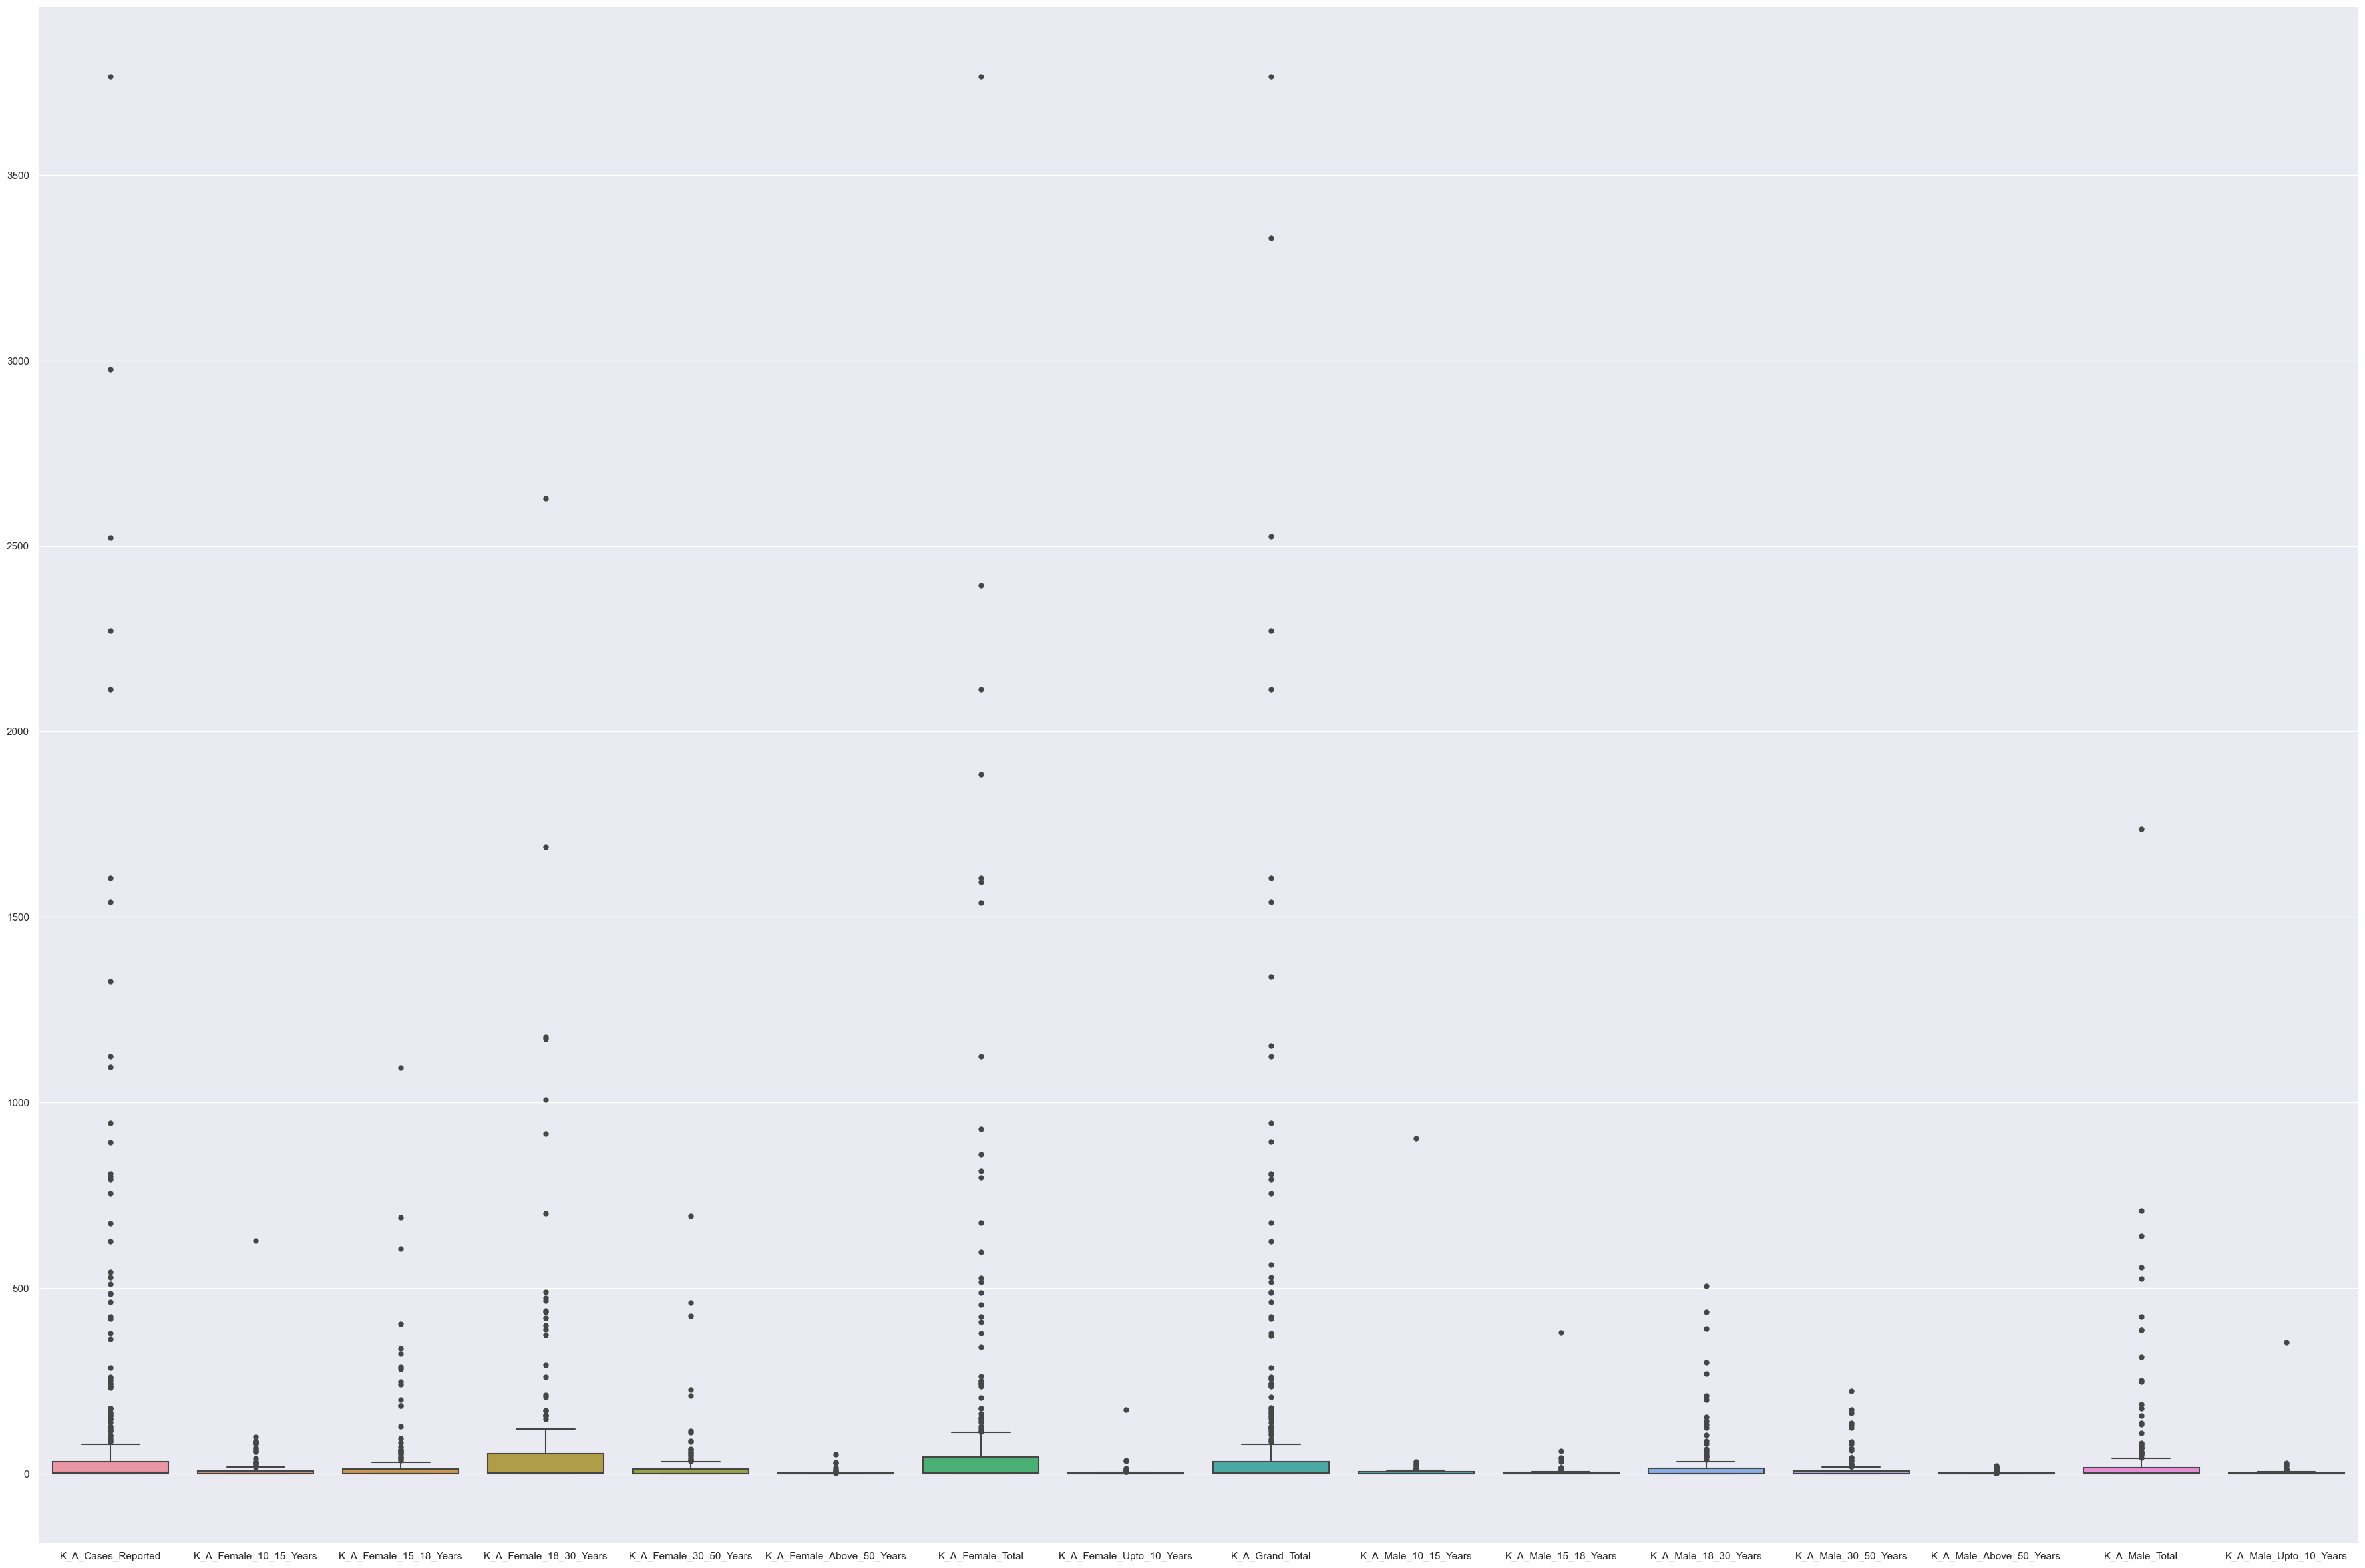

In [72]:
# 1. box plot 
plt.figure(figsize=(45,30))
sns.boxplot(data = df1, flierprops = dict(marker = 'o', color = 'r', markersize=5))
plt.show()

In [73]:
# 2. IQR(Interquartile range)
Q1 = np.percentile(df1, 25)
Q3 = np.percentile(df1, 75)

IQR = Q3 - Q1 
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df1[(df1 < lower_bound) | (df1 > upper_bound)]
outliers.count()

K_A_Cases_Reported           116
K_A_Female_10_15_Years        26
K_A_Female_15_18_Years        81
K_A_Female_18_30_Years       108
K_A_Female_30_50_Years        86
K_A_Female_Above_50_Years      4
K_A_Female_Total             102
K_A_Female_Upto_10_Years       5
K_A_Grand_Total              117
K_A_Male_10_15_Years          11
K_A_Male_15_18_Years           9
K_A_Male_18_30_Years          84
K_A_Male_30_50_Years          34
K_A_Male_Above_50_Years        6
K_A_Male_Total                87
K_A_Male_Upto_10_Years         6
dtype: int64

In [74]:
# Z-score
z_score = stats.zscore(df1)
outliers = np.where(np.abs(z_score) > 3)
outliers

(array([ 89,  89,  89,  89,  89,  94,  94,  94,  94,  94,  95,  95,  95,
         95,  95, 109, 117, 117, 117, 117, 117, 117, 119, 121, 121, 121,
        121, 121, 121, 144, 163, 174, 221, 221, 287, 287, 287, 287, 289,
        289, 289, 290, 290, 295, 295, 295, 295, 295, 295, 295, 295, 295,
        295, 302, 302, 302, 302, 302, 305, 305, 305, 312, 312, 312, 312,
        314, 314, 316, 316, 316, 318, 318, 318, 318, 318, 318, 318, 318],
       dtype=int64),
 array([ 0,  3,  4,  6,  8,  0,  3,  4,  6,  8,  0,  2,  3,  6,  8,  2,  0,
         2,  3,  4,  6,  8,  2,  0,  2,  3,  4,  6,  8,  5, 13, 13,  5, 13,
         7, 11, 12, 13, 11, 12, 14, 11, 14,  0,  1,  2,  6,  7,  8,  9, 10,
        14, 15,  5, 11, 12, 13, 14,  7, 12, 13, 11, 12, 13, 14, 12, 13, 11,
        12, 14,  0,  3,  4,  5,  6,  8, 11, 12], dtype=int64))

<b>Converting categorial values 

In [75]:
# using label encoding to convert categorial values 
le = LabelEncoder()
for i in df2:
    df2[i] = le.fit_transform(df2[i])
df2

,Area_Name,Year,Group_Name,Sub_Group_Name
0,1,0,0,0
1,2,0,0,0
2,4,0,0,0
3,6,0,0,0
4,9,0,0,0
...,...,...,...,...
314,29,0,5,12
315,30,0,5,12
316,31,0,5,12
317,32,0,5,12


In [76]:
# joining df1 and df2 
data2 = pd.concat([df2,df1], axis=1)
data2

,Area_Name,Year,Group_Name,Sub_Group_Name,K_A_Cases_Reported,K_A_Female_10_15_Years,K_A_Female_15_18_Years,K_A_Female_18_30_Years,K_A_Female_30_50_Years,K_A_Female_Above_50_Years,K_A_Female_Total,K_A_Female_Upto_10_Years,K_A_Grand_Total,K_A_Male_10_15_Years,K_A_Male_15_18_Years,K_A_Male_18_30_Years,K_A_Male_30_50_Years,K_A_Male_Above_50_Years,K_A_Male_Total,K_A_Male_Upto_10_Years
0,1,0,0,0,3,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3,0.000000,0.000000,0.000000,2.000000,0.000000,3.0,1.000000
1,2,0,0,0,0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
2,4,0,0,0,6,7.29562,22.854093,62.330986,12.838828,0.653543,99.907285,1.426415,6,2.000000,2.737828,1.000000,2.000000,0.768627,6.0,1.000000
3,6,0,0,0,3,0.00000,3.000000,0.000000,0.000000,0.000000,3.000000,0.000000,3,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
4,9,0,0,0,1,7.29562,22.854093,62.330986,12.838828,0.653543,0.000000,1.426415,1,4.637736,2.737828,15.057348,7.290909,0.768627,1.0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,29,0,5,12,483,15.00000,62.000000,118.000000,31.000000,3.000000,241.000000,12.000000,488,4.000000,2.000000,87.000000,136.000000,11.000000,247.0,7.000000
315,30,0,5,12,33,3.00000,3.000000,9.000000,5.000000,0.000000,20.000000,0.000000,34,1.000000,2.737828,6.000000,6.000000,0.000000,14.0,1.000000
316,31,0,5,12,792,18.00000,13.000000,39.000000,12.000000,0.000000,85.000000,3.000000,792,29.000000,38.000000,390.000000,221.000000,8.000000,707.0,21.000000
317,32,0,5,12,123,7.29562,22.854093,59.000000,29.000000,0.653543,88.000000,1.426415,123,3.000000,5.000000,23.000000,4.000000,0.768627,35.0,2.240876


C:\Users\Praveen Kumar\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


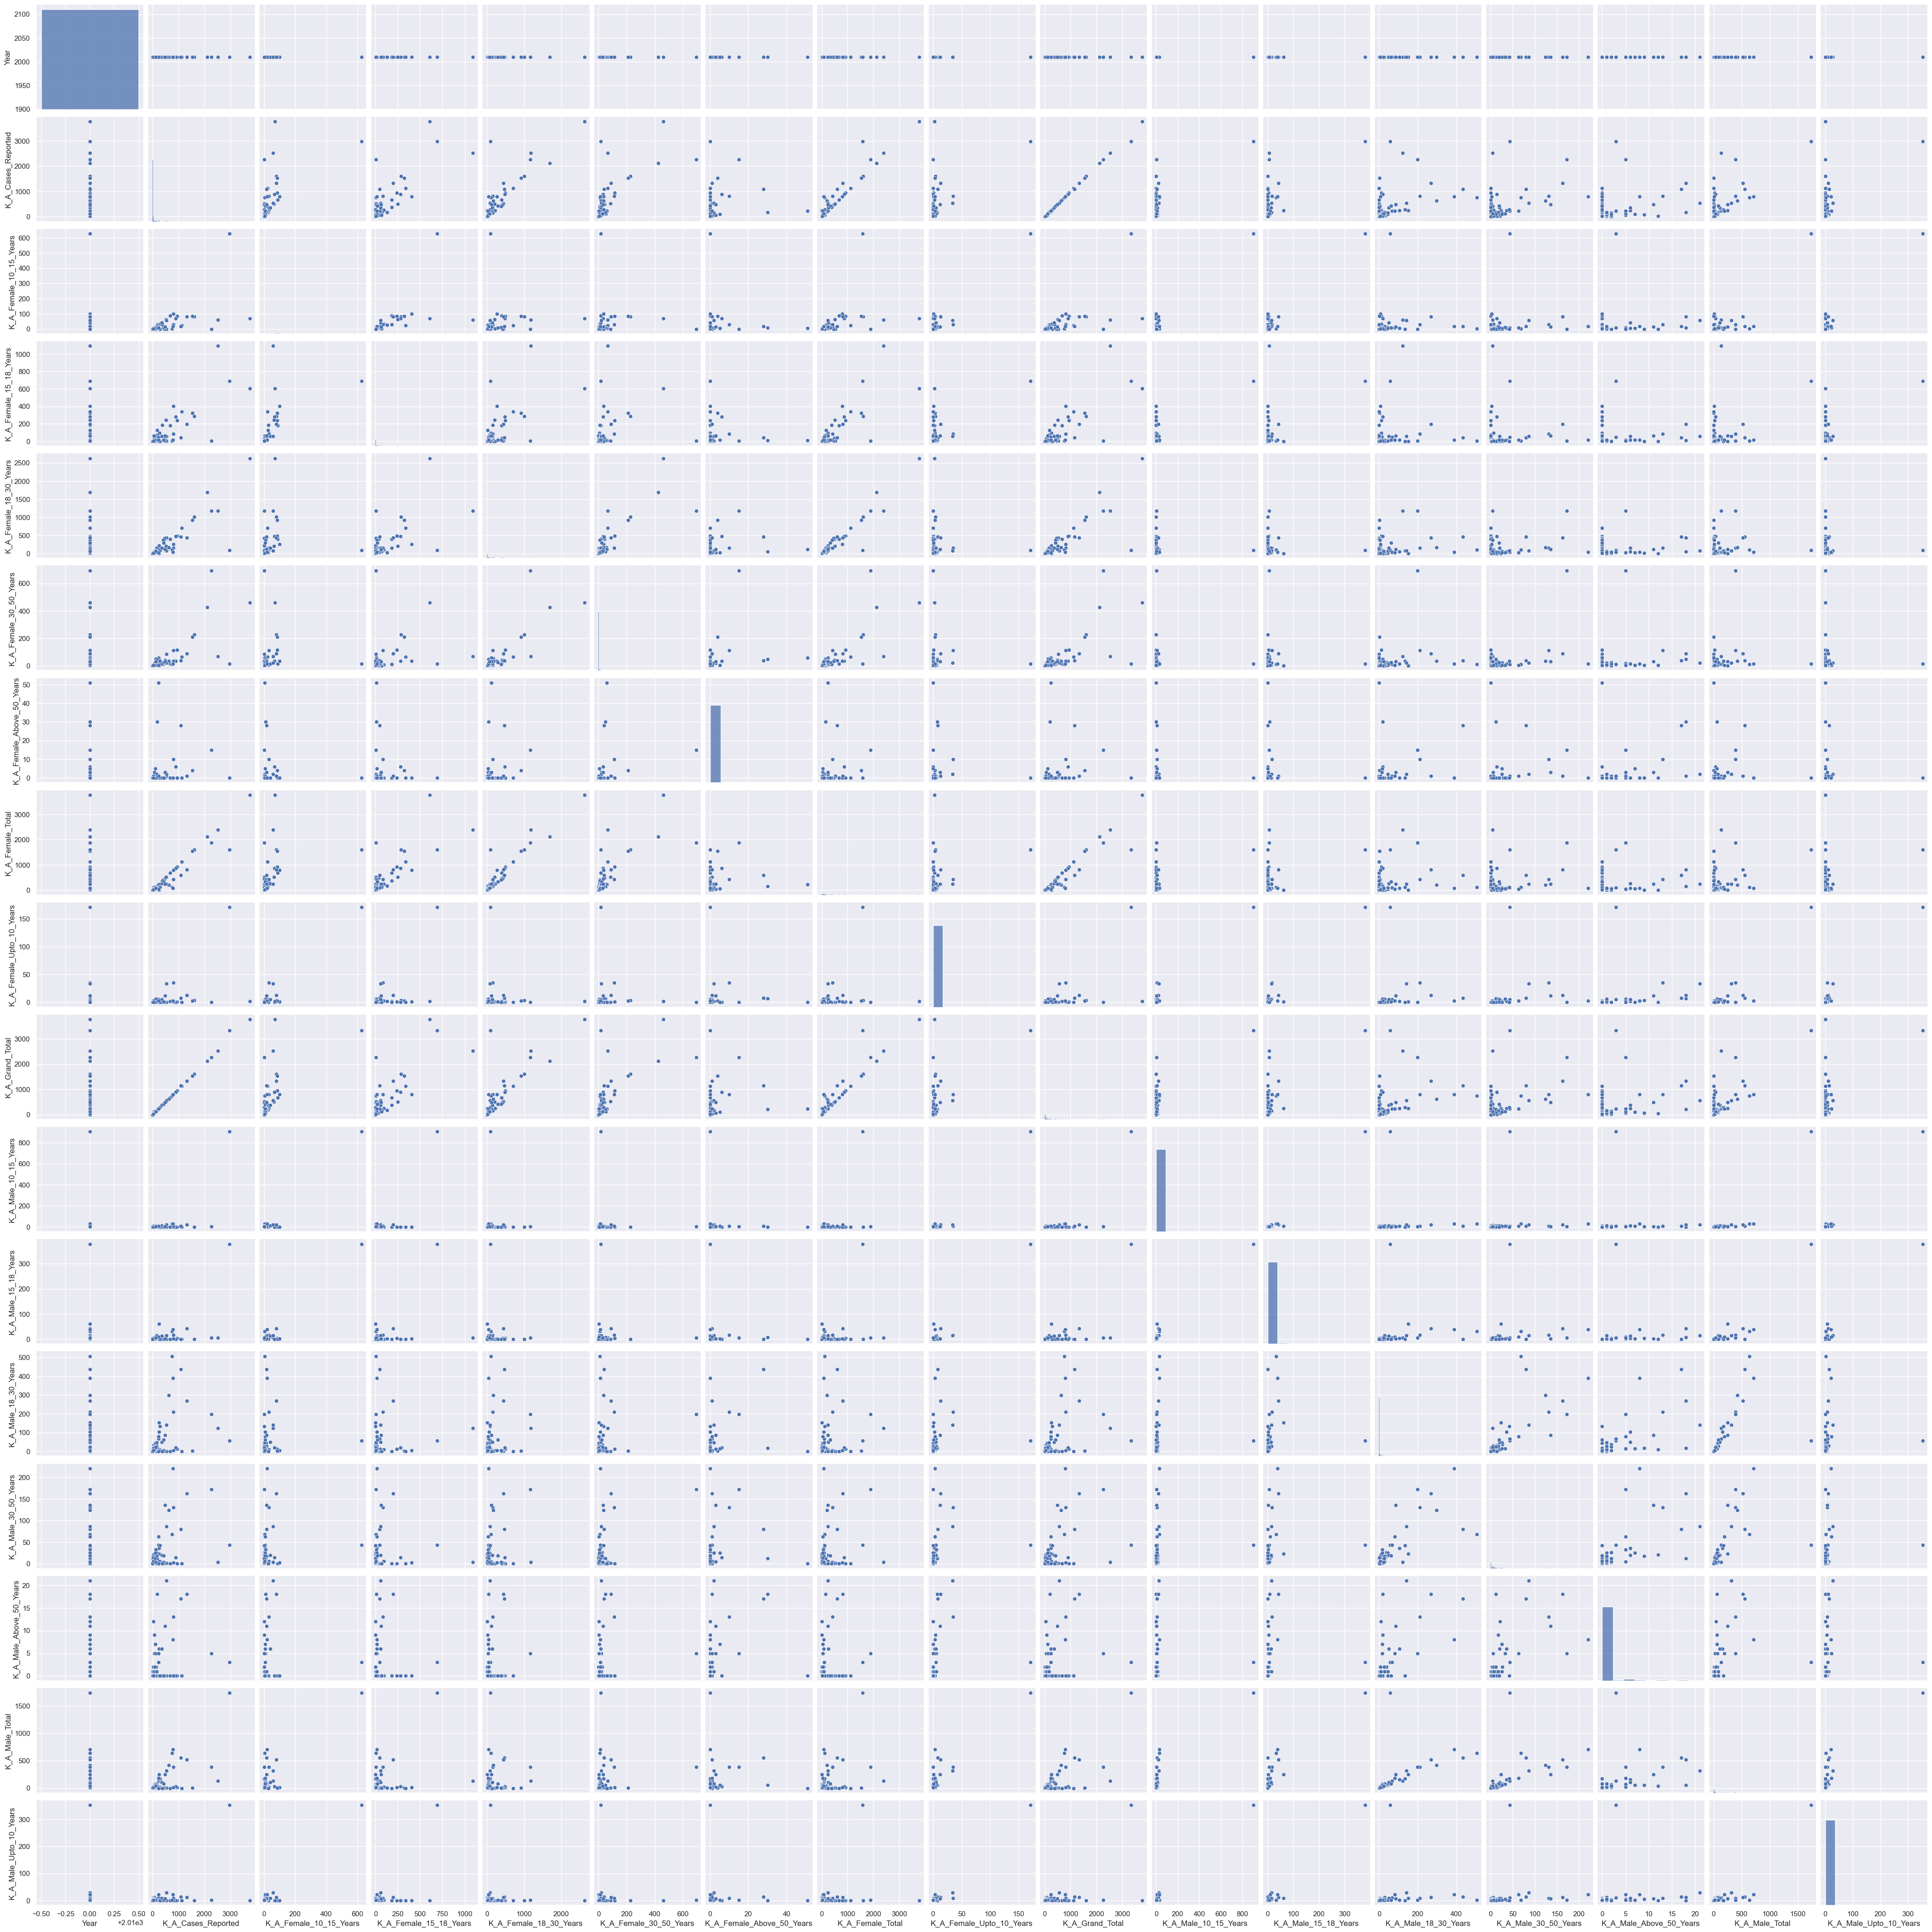

In [77]:
sns.pairplot(data1)

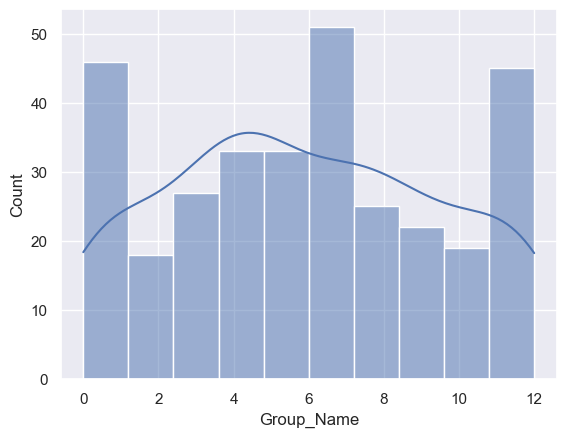

In [78]:
# Histogram 
sns.histplot(data = data2, x ='Group_Name', kde = True )
plt.show()

In [79]:
# using statistical methods to identify and handle outliers 


In [80]:
# finding correlation between features
correlation_matrix = data2.corr()
correlation_matrix

,Area_Name,Year,Group_Name,Sub_Group_Name,K_A_Cases_Reported,K_A_Female_10_15_Years,K_A_Female_15_18_Years,K_A_Female_18_30_Years,K_A_Female_30_50_Years,K_A_Female_Above_50_Years,K_A_Female_Total,K_A_Female_Upto_10_Years,K_A_Grand_Total,K_A_Male_10_15_Years,K_A_Male_15_18_Years,K_A_Male_18_30_Years,K_A_Male_30_50_Years,K_A_Male_Above_50_Years,K_A_Male_Total,K_A_Male_Upto_10_Years
Area_Name,1.000000,NaN,-0.031202,-0.031617,0.050018,-0.028751,0.001239,0.071769,0.088101,0.134656,0.062391,-0.047043,0.047940,-0.045713,-0.051377,-0.027739,0.073015,0.119876,-0.024428,-0.042560
Year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Group_Name,-0.031202,NaN,1.000000,0.796790,-0.108128,-0.065189,-0.105181,-0.120861,-0.080360,0.006155,-0.117659,-0.031210,-0.106186,-0.017035,-0.007031,-0.024597,-0.030422,-0.003116,-0.024542,-0.017086
Sub_Group_Name,-0.031617,NaN,0.796790,1.000000,0.079941,0.077391,-0.026840,-0.034535,0.033705,0.084987,-0.006528,0.143170,0.083974,0.106235,0.142400,0.303583,0.325678,0.273145,0.281049,0.124317
K_A_Cases_Reported,0.050018,NaN,-0.108128,0.079941,1.000000,0.598989,0.790296,0.875100,0.746714,0.186693,0.961889,0.451171,0.998981,0.416190,0.445500,0.401946,0.416862,0.277464,0.562245,0.421990
K_A_Female_10_15_Years,-0.028751,NaN,-0.065189,0.077391,0.598989,1.000000,0.633060,0.223535,0.139339,0.027228,0.462887,0.924264,0.630836,0.928779,0.920622,0.126024,0.175795,0.162288,0.760295,0.928706
K_A_Female_15_18_Years,0.001239,NaN,-0.105181,-0.026840,0.790296,0.633060,1.000000,0.623598,0.331310,0.035699,0.790417,0.424798,0.793504,0.411392,0.416068,0.148837,0.109348,0.102531,0.380594,0.410033
K_A_Female_18_30_Years,0.071769,NaN,-0.120861,-0.034535,0.875100,0.223535,0.623598,1.000000,0.838506,0.149980,0.955338,0.044433,0.857456,0.017584,0.032278,0.202256,0.207816,0.127140,0.139877,0.016682
K_A_Female_30_50_Years,0.088101,NaN,-0.080360,0.033705,0.746714,0.139339,0.331310,0.838506,1.000000,0.251706,0.793410,0.045586,0.730793,0.011427,0.030513,0.224450,0.369009,0.173884,0.177023,0.010334
K_A_Female_Above_50_Years,0.134656,NaN,0.006155,0.084987,0.186693,0.027228,0.035699,0.149980,0.251706,1.000000,0.159471,0.057266,0.187051,-0.003672,0.008001,0.264730,0.226847,0.404245,0.162827,0.010702


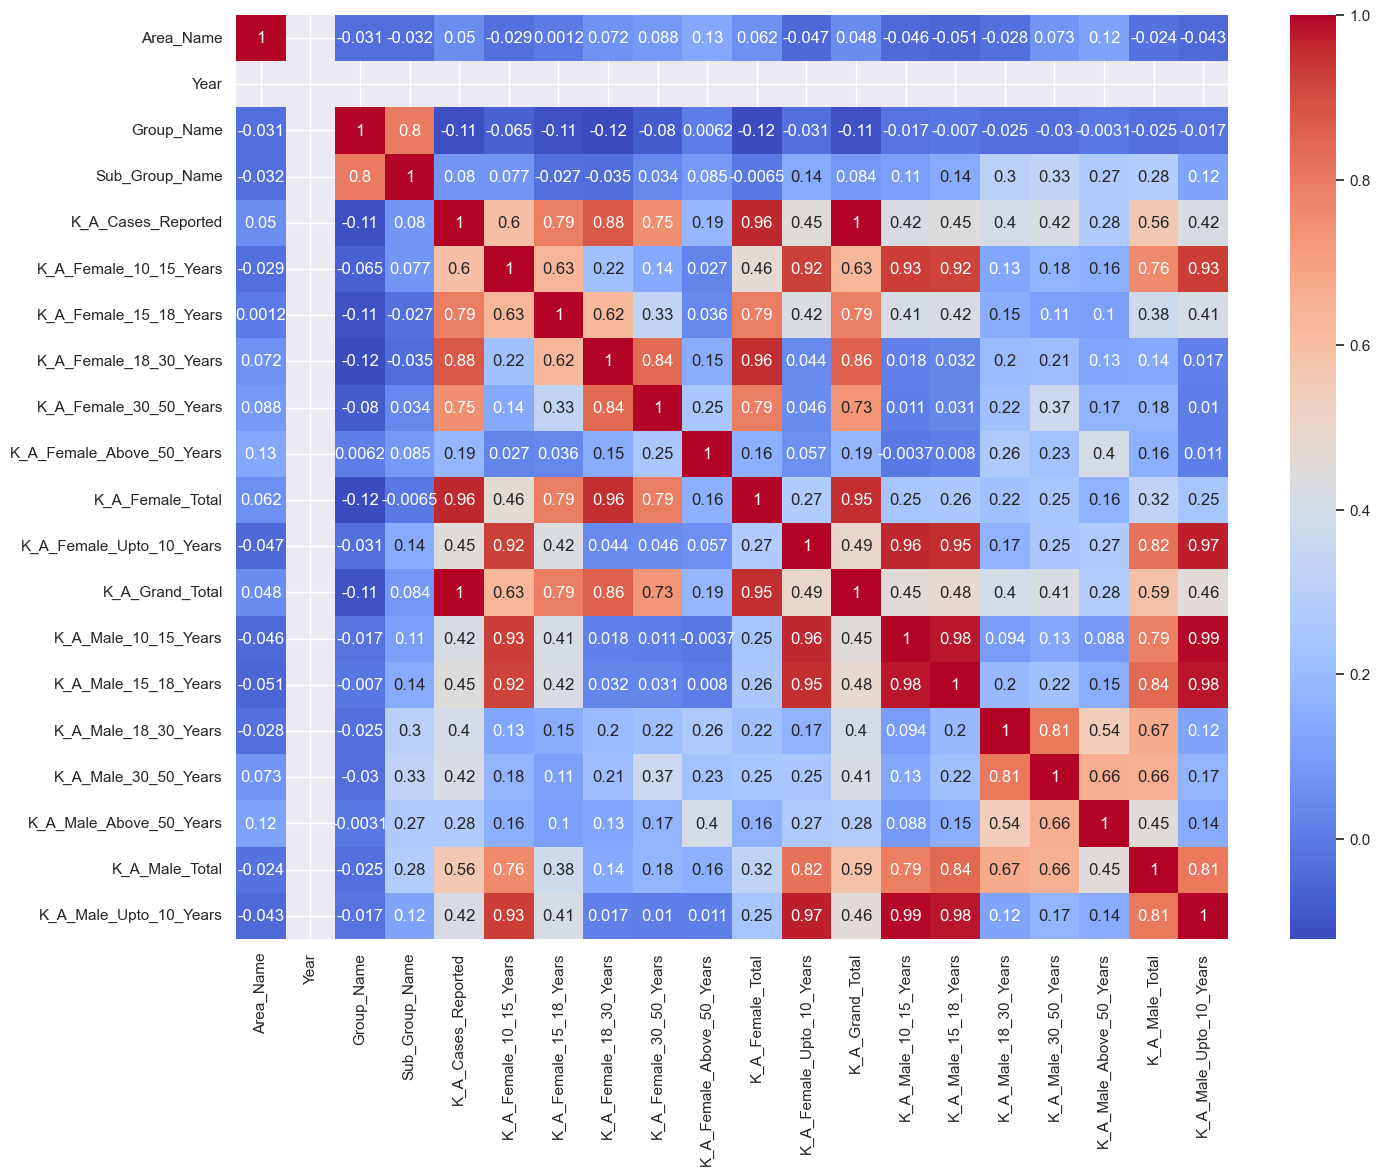

In [81]:
# heatmap
plt.figure(figsize = (16,12))
sns.heatmap(correlation_matrix, annot = True, cmap='coolwarm')
plt.show()

<b> Correlation based feature selection 

In [82]:
high_corr_feature  = correlation_matrix[correlation_matrix > 0.7] 
high_corr_feature

,Area_Name,Year,Group_Name,Sub_Group_Name,K_A_Cases_Reported,K_A_Female_10_15_Years,K_A_Female_15_18_Years,K_A_Female_18_30_Years,K_A_Female_30_50_Years,K_A_Female_Above_50_Years,K_A_Female_Total,K_A_Female_Upto_10_Years,K_A_Grand_Total,K_A_Male_10_15_Years,K_A_Male_15_18_Years,K_A_Male_18_30_Years,K_A_Male_30_50_Years,K_A_Male_Above_50_Years,K_A_Male_Total,K_A_Male_Upto_10_Years
Area_Name,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Group_Name,NaN,NaN,1.00000,0.79679,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sub_Group_Name,NaN,NaN,0.79679,1.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
K_A_Cases_Reported,NaN,NaN,NaN,NaN,1.000000,NaN,0.790296,0.875100,0.746714,NaN,0.961889,NaN,0.998981,NaN,NaN,NaN,NaN,NaN,NaN,NaN
K_A_Female_10_15_Years,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.924264,NaN,0.928779,0.920622,NaN,NaN,NaN,0.760295,0.928706
K_A_Female_15_18_Years,NaN,NaN,NaN,NaN,0.790296,NaN,1.000000,NaN,NaN,NaN,0.790417,NaN,0.793504,NaN,NaN,NaN,NaN,NaN,NaN,NaN
K_A_Female_18_30_Years,NaN,NaN,NaN,NaN,0.875100,NaN,NaN,1.000000,0.838506,NaN,0.955338,NaN,0.857456,NaN,NaN,NaN,NaN,NaN,NaN,NaN
K_A_Female_30_50_Years,NaN,NaN,NaN,NaN,0.746714,NaN,NaN,0.838506,1.000000,NaN,0.793410,NaN,0.730793,NaN,NaN,NaN,NaN,NaN,NaN,NaN
K_A_Female_Above_50_Years,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<b>Model for Male total

In [83]:
# Definig independent variable and dependent variable for male 
x = data2[['Area_Name', 'Group_Name', 'K_A_Male_10_15_Years', 'K_A_Male_15_18_Years', 'K_A_Male_18_30_Years', 'K_A_Male_30_50_Years', 'K_A_Male_Above_50_Years', 'K_A_Male_Upto_10_Years']]
y = data2['K_A_Male_Total']

In [84]:
data2.head()

,Area_Name,Year,Group_Name,Sub_Group_Name,K_A_Cases_Reported,K_A_Female_10_15_Years,K_A_Female_15_18_Years,K_A_Female_18_30_Years,K_A_Female_30_50_Years,K_A_Female_Above_50_Years,K_A_Female_Total,K_A_Female_Upto_10_Years,K_A_Grand_Total,K_A_Male_10_15_Years,K_A_Male_15_18_Years,K_A_Male_18_30_Years,K_A_Male_30_50_Years,K_A_Male_Above_50_Years,K_A_Male_Total,K_A_Male_Upto_10_Years
0,1,0,0,0,3,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3,0.000000,0.000000,0.000000,2.000000,0.000000,3.0,1.0
1,2,0,0,0,0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
2,4,0,0,0,6,7.29562,22.854093,62.330986,12.838828,0.653543,99.907285,1.426415,6,2.000000,2.737828,1.000000,2.000000,0.768627,6.0,1.0
3,6,0,0,0,3,0.00000,3.000000,0.000000,0.000000,0.000000,3.000000,0.000000,3,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
4,9,0,0,0,1,7.29562,22.854093,62.330986,12.838828,0.653543,0.000000,1.426415,1,4.637736,2.737828,15.057348,7.290909,0.768627,1.0,1.0


In [85]:
# Calculating Variance inflation factor for each 
def calculate_vif(x):
    vif_data = pd.DataFrame()
    vif_data['Feature'] = x.columns
    vif_data['VIF'] = [variance_inflation_factor(x.values,i) for i in range(x.shape[1])]
    return vif_data

In [86]:
vif_data = calculate_vif(x)
print("VIF for each feature:\n", vif_data)

VIF for each feature:
                    Feature         VIF
0                Area_Name    2.347214
1               Group_Name    2.264732
2     K_A_Male_10_15_Years  156.567840
3     K_A_Male_15_18_Years   36.414225
4     K_A_Male_18_30_Years    3.432787
5     K_A_Male_30_50_Years    4.157664
6  K_A_Male_Above_50_Years    2.277996
7   K_A_Male_Upto_10_Years  135.703934


In [87]:
# Defining independent variable again after calculating variance inflation factor for male
x1 = data2[['Area_Name', 'Group_Name','K_A_Male_18_30_Years', 'K_A_Male_30_50_Years', 'K_A_Male_Above_50_Years']]
y1 = data2['K_A_Male_Total']

In [88]:
vif_data = calculate_vif(x1)
print("VIF for each feature:\n", vif_data)

VIF for each feature:
                    Feature       VIF
0                Area_Name  2.333784
1               Group_Name  2.239299
2     K_A_Male_18_30_Years  3.104742
3     K_A_Male_30_50_Years  3.938139
4  K_A_Male_Above_50_Years  1.947721


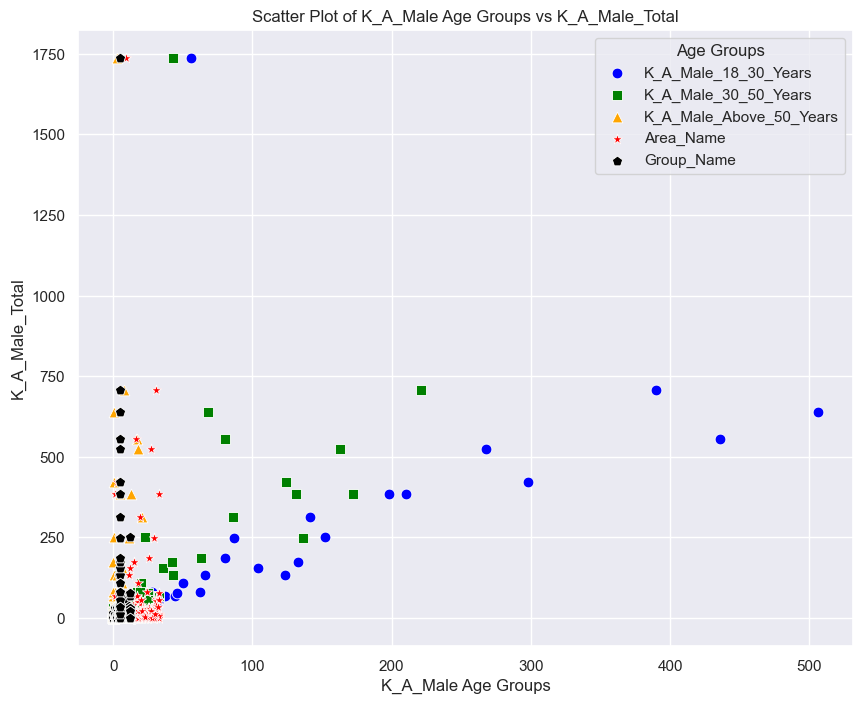

In [89]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=x1['K_A_Male_18_30_Years'], y=y1, label='K_A_Male_18_30_Years', color='blue', marker='o', s = 60)
sns.scatterplot(x=x1['K_A_Male_30_50_Years'], y=y1, label='K_A_Male_30_50_Years', color='green', marker='s', s = 60)
sns.scatterplot(x=x1['K_A_Male_Above_50_Years'], y=y1, label='K_A_Male_Above_50_Years', color='orange', marker='^', s = 60)
sns.scatterplot(x=x1['Area_Name'], y=y1, label='Area_Name', color='red', marker='*', s = 60)
sns.scatterplot(x=x1['Group_Name'], y=y1, label='Group_Name', color='black', marker='p', s = 60)

plt.title('Scatter Plot of K_A_Male Age Groups vs K_A_Male_Total')
plt.xlabel('K_A_Male Age Groups')
plt.ylabel('K_A_Male_Total')

plt.legend(title='Age Groups')



In [90]:
# Spliting the data into training and testing sets 
x1_train, x1_test, y1_train, y1_test = train_test_split(x1, y1, train_size = 0.8, random_state = 1, shuffle = True)

In [91]:
# Scaling the features 
scaler_male = StandardScaler()
x_train_scale = scaler_male.fit_transform(x1_train)
x_test_scale = scaler_male.fit_transform(x1_test)

In [92]:
# Training linear regression model
mlr = LinearRegression()
mlr.fit(x_train_scale, y1_train)

LinearRegression()

In [93]:
# Making prediction on the test set
y_pred = mlr.predict(x_test_scale)


In [94]:
# Evaluating the model 
mse = mean_squared_error(y1_test, y_pred)
r2 = r2_score(y1_test, y_pred)

print(f"Mean Squared Error for Male Prediction: {mse}")
print(f"R^2 Score for male prediction: {r2}")

Mean Squared Error for Male Prediction: 503.7640814419223
R^2 Score for male prediction: 0.9550369474316717


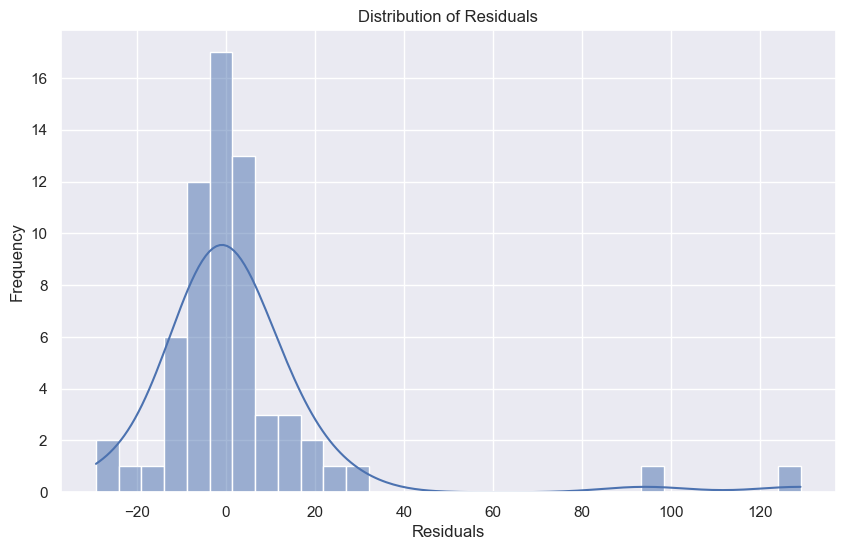

In [95]:
residuals = y1_test - mlr.predict(x_test_scale)
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

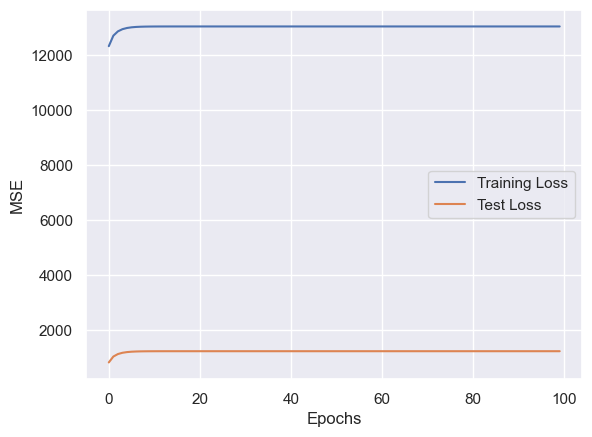

In [96]:
sgd_regressor = SGDRegressor(max_iter=1, tol=None, warm_start=True, penalty=None, learning_rate='constant', eta0=0.01, random_state=42)
train_loss1 = []
test_loss1 = []

epochs = 100
for epoch in range(epochs):
    sgd_regressor.fit(x_train_scale, y1_train)
    
    y_train_pred = sgd_regressor.predict(x_train_scale)
    y_test_pred = sgd_regressor.predict(x_test_scale)
    
    train_mse = mean_squared_error(y1_train, y_train_pred)
    test_mse = mean_squared_error(y1_test, y_test_pred)
    
    train_loss1.append(train_mse)
    test_loss1.append(test_mse)


plt.plot(train_loss1, label='Training Loss')
plt.plot(test_loss1, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.show()

In [97]:
r2sc = r2_score(y1_test, y_test_pred)
r2sc

0.8887986013464729

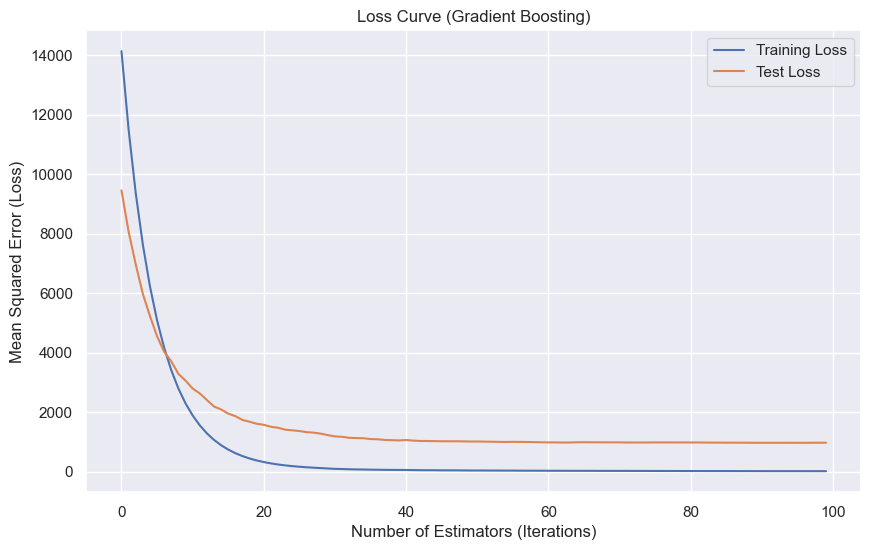

In [98]:
model_male = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# Fit the model
model_male.fit(x_train_scale, y1_train)

# Step 1: Get the staged predictions (predictions after each boosting stage)
train_loss = []
test_loss = []

# Calculate training and test loss for each stage
for y_train_pred1, y_test_pred1 in zip(model_male.staged_predict(x_train_scale), model_male.staged_predict(x_test_scale)):
    train_loss.append(mean_squared_error(y1_train, y_train_pred1))
    test_loss.append(mean_squared_error(y1_test, y_test_pred1))

# Step 2: Plot the loss curve
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss')
plt.plot(test_loss, label='Test Loss')
plt.title('Loss Curve (Gradient Boosting)')
plt.xlabel('Number of Estimators (Iterations)')
plt.ylabel('Mean Squared Error (Loss)')
plt.legend()
plt.grid(True)
plt.show()

In [99]:
r2_sc = r2_score(y1_test, y_test_pred1)
r2_sc

0.9130839569555607

<b>Model for Female total

In [100]:
x_fe = data2[['Area_Name', 'Group_Name', 'K_A_Female_10_15_Years', 'K_A_Female_15_18_Years', 'K_A_Female_18_30_Years', 'K_A_Female_30_50_Years', 'K_A_Female_Above_50_Years', 'K_A_Female_Upto_10_Years']]
y_fe = data2['K_A_Female_Total']

In [101]:
vif_data = calculate_vif(x_fe)
print("VIF for each feature:\n", vif_data)

VIF for each feature:
                      Feature        VIF
0                  Area_Name   2.373716
1                 Group_Name   2.230563
2     K_A_Female_10_15_Years  14.030919
3     K_A_Female_15_18_Years   4.447748
4     K_A_Female_18_30_Years   8.115263
5     K_A_Female_30_50_Years   5.156168
6  K_A_Female_Above_50_Years   1.147674
7   K_A_Female_Upto_10_Years  10.447943


In [102]:
x1_fe = data2[['Area_Name', 'Group_Name', 'K_A_Female_15_18_Years', 'K_A_Female_18_30_Years', 'K_A_Female_30_50_Years', 'K_A_Female_Above_50_Years']]
y1_fe = data2['K_A_Female_Total']

In [103]:
vif_data = calculate_vif(x1_fe)
print("VIF for each feature:\n", vif_data)

VIF for each feature:
                      Feature       VIF
0                  Area_Name  2.364578
1                 Group_Name  2.225032
2     K_A_Female_15_18_Years  2.170773
3     K_A_Female_18_30_Years  6.726648
4     K_A_Female_30_50_Years  4.681456
5  K_A_Female_Above_50_Years  1.129714


In [104]:
x1fe_train, x1fe_test, y1fe_train, y1fe_test = train_test_split(x1_fe, y1_fe, train_size = 0.8, random_state = 1, shuffle = True)

In [105]:
scaler_female = StandardScaler()
x_fe_train_scale = scaler_female.fit_transform(x1fe_train)
x_fe_test_scale = scaler_female.fit_transform(x1fe_test)

In [106]:
mlr_fe = LinearRegression()
mlr_fe.fit(x_fe_train_scale, y1fe_train)

LinearRegression()

In [107]:
y_fe_pred = mlr_fe.predict(x_fe_test_scale)

In [108]:
mse_fe = mean_squared_error(y1fe_test, y_fe_pred)
r2_fe = r2_score(y1fe_test, y_fe_pred)

print(f"Mean Squared Error for Male Prediction: {mse_fe}")
print(f"R^2 Score for male prediction: {r2_fe}")

Mean Squared Error for Male Prediction: 12884.222959702556
R^2 Score for male prediction: 0.9293062277915747


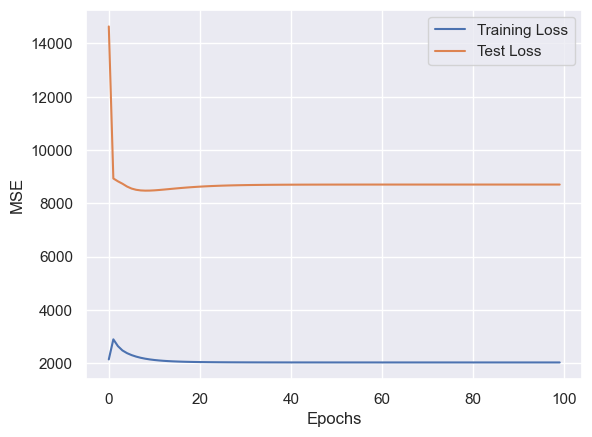

In [109]:
sgd_regressor_fe = SGDRegressor(max_iter=1, tol=None, warm_start=True, penalty=None, learning_rate='constant', eta0=0.01, random_state=42)
train_loss_fe = []
test_loss_fe = []

epochs = 100
for epoch in range(epochs):
    sgd_regressor_fe.fit(x_fe_train_scale, y1fe_train)
    
    y_fe_train_pred = sgd_regressor_fe.predict(x_fe_train_scale)
    y_fe_test_pred = sgd_regressor_fe.predict(x_fe_test_scale)
    
    train_mse_fe = mean_squared_error(y1fe_train, y_fe_train_pred)
    test_mse_fe = mean_squared_error(y1fe_test, y_fe_test_pred)
    
    train_loss_fe.append(train_mse_fe)
    test_loss_fe.append(test_mse_fe)


plt.plot(train_loss_fe, label='Training Loss')
plt.plot(test_loss_fe, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.show()

In [110]:
r2sc_fe = r2_score(y1fe_test, y_fe_test_pred)
r2sc_fe

0.952244737622151

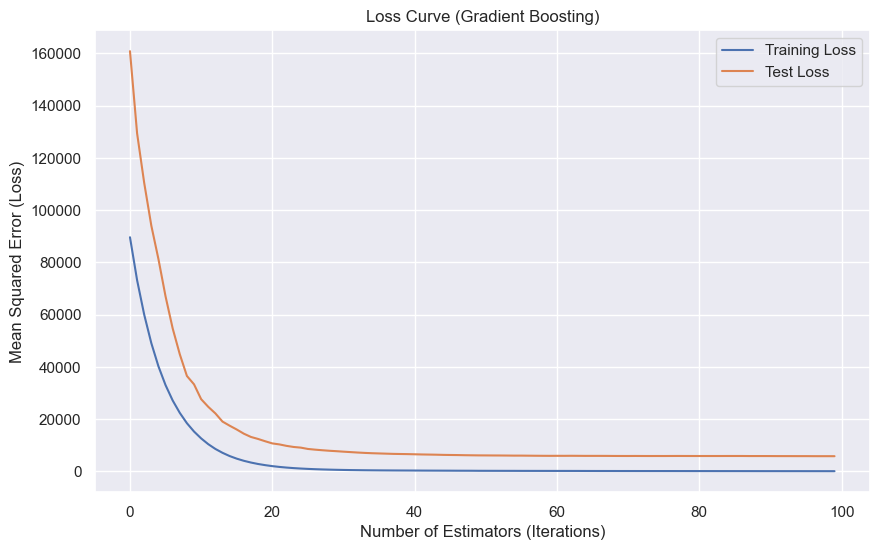

In [111]:
model_female = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# Fit the model
model_female.fit(x_fe_train_scale, y1fe_train)

# Step 1: Get the staged predictions (predictions after each boosting stage)
train_lossfe = []
test_lossfe = []

# Calculate training and test loss for each stage
for y_fe_train_pred1, y_fe_test_pred1 in zip(model_female.staged_predict(x_fe_train_scale), model_female.staged_predict(x_fe_test_scale)):
    train_lossfe.append(mean_squared_error(y1fe_train, y_fe_train_pred1))
    test_lossfe.append(mean_squared_error(y1fe_test, y_fe_test_pred1))

# Step 2: Plot the loss curve
plt.figure(figsize=(10, 6))
plt.plot(train_lossfe, label='Training Loss')
plt.plot(test_lossfe, label='Test Loss')
plt.title('Loss Curve (Gradient Boosting)')
plt.xlabel('Number of Estimators (Iterations)')
plt.ylabel('Mean Squared Error (Loss)')
plt.legend()
plt.grid(True)
plt.show()

In [112]:
r2_sc_fe = r2_score(y1fe_test, y_fe_test_pred1)
r2_sc_fe

0.9680706189886131

In [113]:
# Saving the models and scalers
with open('models/model_male.pkl', 'wb') as f:
    pickle.dump(model_male, f)

In [114]:
with open('models/model_female.pkl', 'wb') as f:
    pickle.dump(model_female, f)

In [115]:
with open('models/scaler_male.pkl', 'wb') as f:
    pickle.dump(scaler_male, f)

In [116]:
with open('models/scaler_female.pkl', 'wb') as f:
    pickle.dump(scaler_female, f)

In [117]:
def make_prediction(area, group_name, gender):
    area_data = data2[(data2['Area_Name'] == area) & (data2['Group_Name'] == group_name)]
    
    if area_data.empty:
        return "No data available for the selected Area and Group Name."
    
    if gender == 'Male':
        input_data = area_data[['Area_Name', 'Group_Name','K_A_Male_18_30_Years', 'K_A_Male_30_50_Years', 'K_A_Male_Above_50_Years']].values
        input_data_scaled = scaler_male.transform(input_data)
        prediction = model_male.predict(input_data_scaled)[0]
    else:
        input_data = area_data[['Area_Name', 'Group_Name', 'K_A_Female_15_18_Years', 'K_A_Female_18_30_Years', 'K_A_Female_30_50_Years', 'K_A_Female_Above_50_Years']].values 
        input_data_scaled = scaler_female.transform(input_data) 
        prediction = model_female.predict(input_data_scaled)[0]
        
    return prediction

In [118]:
make_prediction(0, 4, 'Male')

C:\Users\Praveen Kumar\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


22.923903912752635

In [120]:
st.title("Predict Male and Female Total Cases")

# Load unique values for Area and Group names from the dataset (convert to numeric dropdowns)
area_options = data2['Area_Name'].unique().tolist()
group_name_options = data2['Group_Name'].unique().tolist()

# Dropdown menus for Area and Group
area = st.selectbox("Select Area", options=area_options)
group_name = st.selectbox("Select Group Name", options=group_name_options)

# Gender dropdown
gender = st.selectbox("Select Gender", ['Male', 'Female'])

# Prediction
if st.button("Predict"):
    prediction = make_prediction(area, group_name, gender)
    st.write(f"The prediction for {gender} in {area} under group {group_name} is: {prediction}")